# Libraries and Params

In [24]:
# Importing libraries
import os
import cv2
import random 
import numpy as np 
import pandas as pd 
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, InceptionV3
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, concatenate, Conv2D, MaxPooling2D, Flatten
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [25]:
# Settig parameters
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 7
LEARNING_RATE = 1e-4
NUM_CLASSES = 3

# Data Exploration

In [26]:
# Ignoring warning messages
import warnings
warnings.filterwarnings("ignore")

In [27]:
# Loading the dataset CSV files
train = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')
train.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


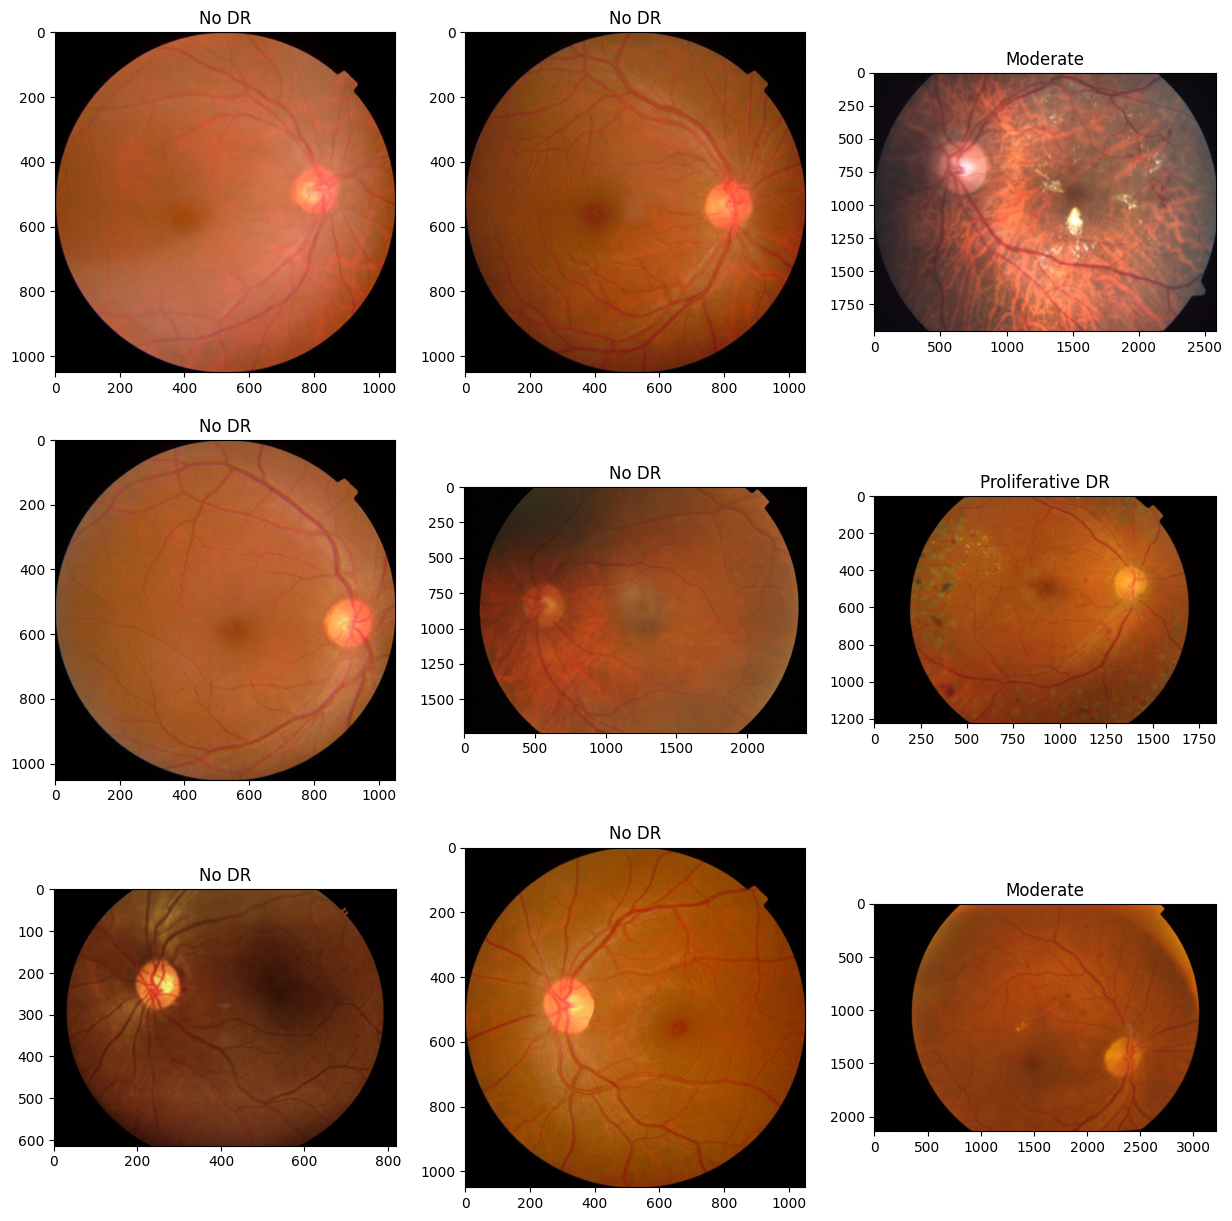

In [28]:
label_dic = {
    "0":"No DR",
    "1" : "Mild",
    "2":"Moderate",
    "3":"Severe",
    "4":"Proliferative DR"
}

#Checking Some Samples and Their Label

rows=3
cols = 3
count = 0

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15,15))

indx = random.sample(range(train.shape[0]),rows * cols)

for i in range(rows):
    for j in range(cols):        
        if count < len(indx):
            img_path = "/kaggle/input/aptos2019-blindness-detection/train_images/"+train.iloc[indx[count],0]+".png"
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i,j].set_title(label_dic[str(train.iloc[indx[count],1])])
            count+=1

In [29]:
# Appending '.png' to file names
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")

# Creating Copy
df_origional = train.copy()

# Combining classes into 3 categories
train['diagnosis'] = train['diagnosis'].replace({0: 0, 1: 1, 2: 1, 3: 2, 4: 2})

label_dict = {
    0: 'No Disease',
    1: 'Mild Disease',
    2: 'Severe Disease'
}

class_distribution = train['diagnosis'].value_counts().sort_index()
class_distribution.index = class_distribution.index.map(label_dict)

print("Updated class distribution:\n", class_distribution)

Updated class distribution:
 diagnosis
No Disease        1805
Mild Disease      1369
Severe Disease     488
Name: count, dtype: int64


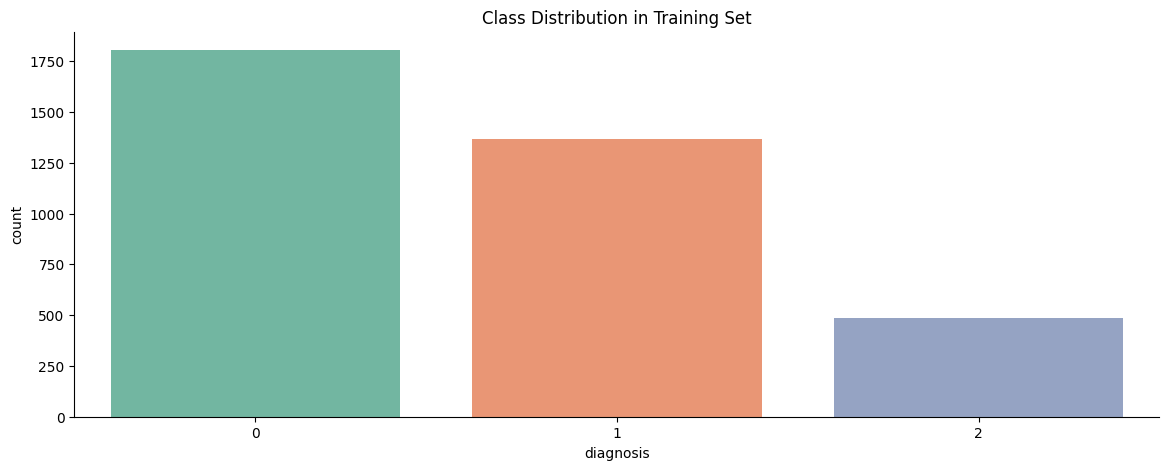

In [30]:
# Bar chart show the distribution of classes
f, ax = plt.subplots(figsize=(14, 5))
ax = sns.countplot(x="diagnosis", data=train, palette="Set2")
sns.despine()
plt.title("Class Distribution in Training Set")
plt.show()

In [31]:
train['diagnosis'] = train['diagnosis'].astype('str')

In [32]:
# Combining classes into 3 categories
df_binary = df_origional[df_origional.diagnosis.isin([0, 4])]
df_binary.replace({4: 1}, inplace=True)

X_binary = []
y_binary = []

for i, row in tqdm(df_binary.sample(len(df_binary)).iterrows()):
    image_name = row.id_code
    image_path = os.path.join("/kaggle/input/aptos2019-blindness-detection/train_images", image_name)
    label = row.diagnosis

    # Read image
    image = cv2.imread(image_path)
    if image is not None:  # Check if image is loaded properly
        # Convert image to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image to the defined IMAGE_SIZE
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

        # Rescale pixel values to the range [0, 1]
        image = image / 255.0

        # Append processed image and label to respective lists
        X_binary.append(image)
        y_binary.append(label)
    else:
        print(f"Image not found or unable to read: {image_path}")

# Convert lists to NumPy arrays
X_binary = np.array(X_binary, dtype='float32')
y_binary = np.array(y_binary, dtype='int32')

print(f"Shape of X (images): {X_binary.shape}")
print(f"Shape of y (labels): {y_binary.shape}")

2100it [02:24, 14.56it/s]


Shape of X (images): (2100, 224, 224, 3)
Shape of y (labels): (2100,)


In [33]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

Shape of X_train: (1680, 224, 224, 3), y_train: (1680,)
Shape of X_test: (420, 224, 224, 3), y_test: (420,)


In [34]:
# ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,       # Random rotation
    width_shift_range=0.2,   # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,         # Shearing
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Horizontal flipping
    fill_mode="nearest"      # Fill mode for empty pixels
)

# Test data generator (no augmentation, only rescaling if needed)
test_datagen = ImageDataGenerator()


# Creating data generators
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data generators are ready.")

Data generators are ready.


In [35]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Function to create callbacks
def create_callbacks(checkpoint_path):
    # Create a ModelCheckpoint callback
    checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path,  # Path to save the model
        monitor='val_loss',       # Metric to monitor
        save_best_only=True,      # Save only the best model
        mode='min',               # Mode to minimize val_loss
        verbose=1                 # Print saving details
    )
    
    # Create an EarlyStopping callback
    early_stopping_callback = EarlyStopping(
        monitor='val_loss',       # Metric to monitor
        patience=7,               # Number of epochs with no improvement to stop
        mode='min',               # Mode to minimize val_loss
        verbose=1                 # Print stopping details
    )

    return checkpoint_callback, early_stopping_callback

In [36]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Fusion model with adjustable hyperparameters
def build_fusion_model_hyper(num_classes, input_shape=(224, 224, 3), dropout_rate=0.5, dense_units=256, learning_rate=1e-4, activation="relu"):
    input_layer = Input(shape=input_shape)

    # EfficientNetB0
    efficient_net = EfficientNetB0(include_top=False, input_tensor=input_layer, weights='imagenet')
    for i, layer in enumerate(efficient_net.layers):
        layer.trainable = i < 10
    efficient_output = GlobalAveragePooling2D()(efficient_net.output)

    # InceptionV3
    inception_v3 = InceptionV3(include_top=False, input_tensor=input_layer, weights='imagenet')
    for i, layer in enumerate(inception_v3.layers):
        layer.trainable = i < 10
    inception_output = GlobalAveragePooling2D()(inception_v3.output)

    # Concatenate outputs
    combined_output = concatenate([efficient_output, inception_output])

    # Fully connected layers with dropout
    x = Dense(dense_units, activation=activation)(combined_output)
    x = Dropout(dropout_rate)(x)
    x = Dense(dense_units // 2, activation=activation)(x)
    x = Dropout(dropout_rate)(x)

    # Output Layer
    if num_classes == 2:
        output_layer = Dense(1, activation='sigmoid')(x)
    else:
        output_layer = Dense(num_classes, activation='softmax')(x)
        
    model = Model(inputs=input_layer, outputs=output_layer)

    # Compile the model with the given learning rate
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Callback creation
checkpoint_path = "best_hyper_fusion_model.keras"
checkpoint_callback, early_stopping_callback = create_callbacks(checkpoint_path)

In [37]:
# Hyperparameter tuning: Trying combinations
combinations = [
    {'dropout_rate': 0.3, 'dense_units': 256, 'learning_rate': 1e-4, "activation": "relu"},
    {'dropout_rate': 0.4, 'dense_units': 128, 'learning_rate': 5e-4, "activation": "relu"},
    {'dropout_rate': 0.4, 'dense_units': 128, 'learning_rate': 5e-4, "activation": "tanh"},
    {'dropout_rate': 0.5, 'dense_units': 256, 'learning_rate': 1e-3, "activation": "relu"},
    {'dropout_rate': 0.5, 'dense_units': 256, 'learning_rate': 1e-3, "activation": "tanh"},
]

results = []
models = []

for params in combinations:
    print(f"Training model with params: {params}")
    
    # Build and train the model
    model = build_fusion_model_hyper(
        num_classes=2,
        dropout_rate=params['dropout_rate'],
        dense_units=params['dense_units'],
        learning_rate=params['learning_rate']
    )
    
    checkpoint_callback, early_stopping_callback = create_callbacks(checkpoint_path)
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=EPOCHS,
        callbacks=[checkpoint_callback, early_stopping_callback],
        verbose=0
    )
    
    # Evaluate the model
    y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Save the results
    results.append({
        'Dropout Rate': params['dropout_rate'],
        'Dense Units': params['dense_units'],
        'Learning Rate': params['learning_rate'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    models.append(model)

Training model with params: {'dropout_rate': 0.3, 'dense_units': 256, 'learning_rate': 0.0001, 'activation': 'relu'}

Epoch 1: val_loss improved from inf to 0.26286, saving model to best_hyper_fusion_model.keras

Epoch 2: val_loss improved from 0.26286 to 0.19401, saving model to best_hyper_fusion_model.keras

Epoch 3: val_loss improved from 0.19401 to 0.18638, saving model to best_hyper_fusion_model.keras

Epoch 4: val_loss improved from 0.18638 to 0.17280, saving model to best_hyper_fusion_model.keras

Epoch 5: val_loss improved from 0.17280 to 0.17278, saving model to best_hyper_fusion_model.keras

Epoch 6: val_loss improved from 0.17278 to 0.17066, saving model to best_hyper_fusion_model.keras

Epoch 7: val_loss did not improve from 0.17066
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 687ms/step
Training model with params: {'dropout_rate': 0.4, 'dense_units': 128, 'learning_rate': 0.0005, 'activation': 'relu'}

Epoch 1: val_loss improved from inf to 0.34809, saving model to best_hyper_fusion_mod

In [38]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)
print("Hyperparameter Tuning Results\n", results_df.to_markdown())

# Display best model parameters
best_params = results_df.loc[results_df['Accuracy'].idxmax()]
print("Best Params: ", best_params)

Hyperparameter Tuning Results
 |    |   Dropout Rate |   Dense Units |   Learning Rate |   Accuracy |   Precision |   Recall |   F1 Score |
|---:|---------------:|--------------:|----------------:|-----------:|------------:|---------:|-----------:|
|  0 |            0.3 |           256 |          0.0001 |   0.907143 |    1        | 0.338983 |   0.506329 |
|  1 |            0.4 |           128 |          0.0005 |   0.916667 |    1        | 0.40678  |   0.578313 |
|  2 |            0.4 |           128 |          0.0005 |   0.914286 |    0.96     | 0.40678  |   0.571429 |
|  3 |            0.5 |           256 |          0.001  |   0.95     |    1        | 0.644068 |   0.783505 |
|  4 |            0.5 |           256 |          0.001  |   0.919048 |    0.931034 | 0.457627 |   0.613636 |
Best Params:  Dropout Rate       0.500000
Dense Units      256.000000
Learning Rate      0.001000
Accuracy           0.950000
Precision          1.000000
Recall             0.644068
F1 Score           0.783

In [39]:
def evaluate_model(y_true, y_pred, class_labels):
    # Calculating accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    # Displaying classification report
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

    # Generating and ploting the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # Plotting the ROC curve for each class
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = y_true_bin.shape[1]
    y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2])
    plt.figure(figsize=(10, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {label_dict[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Each Class')
    plt.legend(loc='lower right')
    plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Accuracy: 0.95
Precision: 0.9527486910994764
Recall: 0.95
F1 Score: 0.9452942237515783
Classification Report:
               precision    recall  f1-score   support

       No DR       0.95      1.00      0.97       361
   Severe DR       1.00      0.64      0.78        59

    accuracy                           0.95       420
   macro avg       0.97      0.82      0.88       420
weighted avg       0.95      0.95      0.95       420



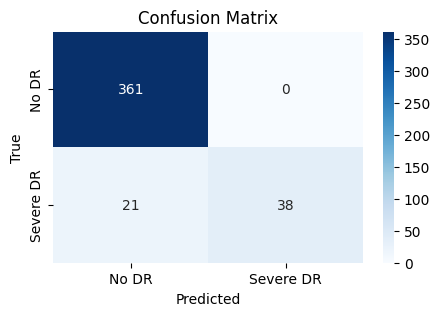

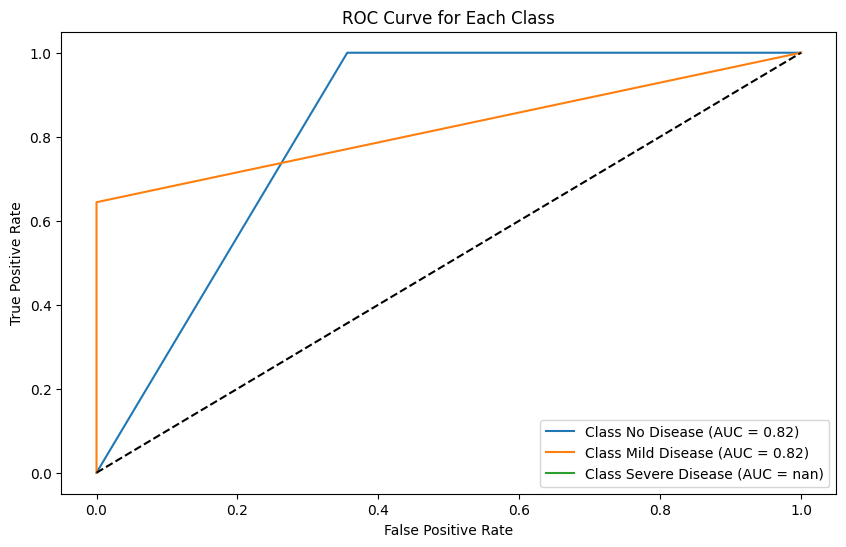

In [48]:
best_model = models[results_df['Accuracy'].idxmax()]


# Getting true labels and predictions
y_true = y_test
y_pred = [0 if i<0.5 else 1 for i in best_model.predict(X_test)]
class_labels = ["No DR", "Severe DR"]
evaluate_model(y_true, y_pred, class_labels)